## Ex:2 Data Wrangling and Transformation 
### Objective

To perform data wrangling and transformation on a dataset using Python and Pandas by handling missing values, removing duplicates, correcting data types, filtering data, and transforming variables into a suitable format for data analysis and machine learning.



##  Dataset Description

The dataset contains information about **student academic performance, educational background, MBA specialization, and placement salary**.

###  Dataset Attributes

| Column | Description |
|:---|:---|
| `sl_no` | Serial number / student identifier |
| `gender` | Gender of the student |
| `hsc_p` | Higher Secondary / 12th percentage |
| `hsc_s` | Higher Secondary stream |
| `degree_p` | Undergraduate degree percentage |
| `degree_t` | Undergraduate degree type |
| `etest_p` | Employability / entrance test percentage |
| `specialisation` | MBA specialization |
| `mba_p` | MBA percentage |
| `salary` | Salary offered after placement |

---

## Experiment Question

 **Using the given student placement dataset, perform data wrangling and transformation by handling missing values, scaling numerical features, detecting and treating outliers, encoding categorical variables, and generating a final model-ready dataset.**




Data wrangling and transformation is the process of converting raw student placement data into a clean, consistent, and machine-learning-ready dataset. In this experiment, the given student placement dataset is first loaded into a Pandas DataFrame and explored by examining its rows, columns, data types, and descriptive statistics. Missing values are then identified and handled by removing records with missing `salary` values and replacing missing values in `hsc_p`, `degree_p`, and `etest_p` with their respective mean values. The numerical attributes such as `hsc_p`, `degree_p`, `etest_p`, and `salary` are transformed using feature-scaling techniques such as `StandardScaler` and `MinMaxScaler` to bring the variables into suitable numerical ranges. The dataset is then divided into input features (`X`) and the target variable (`Y`), where `salary` is considered the target. The preprocessed data is saved as `Pre.csv` for further processing. Next, possible outliers in the `salary` attribute are identified using a boxplot and statistically detected using the Z-score method, where values with an absolute Z-score greater than 3 are considered potential outliers. Outliers are also treated using the capping and flooring method by calculating the 5th and 95th percentiles and replacing values outside these limits with the corresponding boundary values. The salary distribution before and after outlier treatment is then compared using visualization. Since the dataset also contains categorical attributes such as `gender`, `hsc_s`, `degree_t`, and `specialisation`, these variables are converted into numerical representations using `LabelEncoder` and One-Hot Encoding. Finally, the completely transformed dataset is verified for missing values, data types, dimensions, and numerical representation, and the resulting model-ready dataset is saved as `Final.csv`. Thus, the experiment demonstrates the complete workflow of preparing real-world tabular data for data analysis and machine-learning applications.

## Step 1: Start by importing the necessary Python libraries for data preprocessing.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore
from scipy import stats
from sklearn.preprocessing import LabelEncoder

## Step 2: Load the placement dataset into a Pandas Dataframe.

In [2]:
DF = pd.read_csv("data.csv")
DF.head()


,sl_no,gender,hsc_p,hsc_s,degree_p,degree_t,etest_p,specialisation,mba_p,salary
0,1,M,91.00,Commerce,58.00,Sci&Tech,55.0,Mkt&HR,58.80,270000.0
1,2,M,78.33,Science,77.48,Sci&Tech,86.5,Mkt&Fin,66.28,200000.0
2,3,M,NaN,Arts,64.00,Comm&Mgmt,75.0,Mkt&Fin,57.80,250000.0
3,4,M,52.00,Science,NaN,Sci&Tech,66.0,Mkt&HR,59.43,NaN
4,5,M,73.60,Commerce,73.30,Comm&Mgmt,96.8,Mkt&Fin,55.50,425000.0


## Step 3:Take a quick look at the data to understand its structure and identify any missing values or anomalies.

In [3]:
DF.head(10)

,sl_no,gender,hsc_p,hsc_s,degree_p,degree_t,etest_p,specialisation,mba_p,salary
0,1,M,91.00,Commerce,58.00,Sci&Tech,55.00,Mkt&HR,58.80,270000.0
1,2,M,78.33,Science,77.48,Sci&Tech,86.50,Mkt&Fin,66.28,200000.0
2,3,M,NaN,Arts,64.00,Comm&Mgmt,75.00,Mkt&Fin,57.80,250000.0
3,4,M,52.00,Science,NaN,Sci&Tech,66.00,Mkt&HR,59.43,NaN
4,5,M,73.60,Commerce,73.30,Comm&Mgmt,96.80,Mkt&Fin,55.50,425000.0
5,6,M,49.80,Science,67.25,Sci&Tech,55.00,Mkt&Fin,51.58,NaN
6,7,F,49.20,Commerce,79.00,Comm&Mgmt,74.28,Mkt&Fin,53.29,NaN
7,8,M,64.00,Science,66.00,Sci&Tech,67.00,Mkt&Fin,62.14,252000.0
8,9,M,79.00,Commerce,72.00,Comm&Mgmt,91.34,Mkt&Fin,61.29,231000.0
9,10,M,70.00,Commerce,61.00,Comm&Mgmt,54.00,Mkt&Fin,52.21,NaN


In [4]:
DF.shape

(215, 10)

In [5]:
DF.columns

Index(['sl_no', 'gender', 'hsc_p', 'hsc_s', 'degree_p', 'degree_t', 'etest_p',
       'specialisation', 'mba_p', 'salary'],
      dtype='str')

In [6]:
DF.dtypes

sl_no               int64
gender                str
hsc_p             float64
hsc_s                 str
degree_p          float64
degree_t              str
etest_p           float64
specialisation        str
mba_p             float64
salary            float64
dtype: object

In [7]:
DF.describe()

,sl_no,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,210.000000,213.000000,211.000000,214.000000,148.000000
mean,108.000000,66.503000,66.420610,72.093649,62.254813,288655.405405
std,62.209324,10.904205,7.322786,13.340195,5.836962,93457.452420
min,1.000000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,61.000000,61.000000,60.000000,57.922500,240000.000000
50%,108.000000,65.000000,66.000000,70.000000,61.950000,265000.000000
75%,161.500000,73.000000,72.000000,84.000000,66.187500,300000.000000
max,215.000000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [8]:
DF.isnull().sum()

sl_no              0
gender             0
hsc_p              5
hsc_s              0
degree_p           2
degree_t           0
etest_p            4
specialisation     0
mba_p              1
salary            67
dtype: int64

In [9]:
DF.info()



<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   hsc_p           210 non-null    float64
 3   hsc_s           215 non-null    str    
 4   degree_p        213 non-null    float64
 5   degree_t        215 non-null    str    
 6   etest_p         211 non-null    float64
 7   specialisation  215 non-null    str    
 8   mba_p           214 non-null    float64
 9   salary          148 non-null    float64
dtypes: float64(5), int64(1), str(4)
memory usage: 16.9 KB


#### The method isnull() checks each element in the DataFrame (or Series) to see if it is NaN (Not a Number) or None (missing value).
It returns a DataFrame (or Series) of the same shape as the input, with Boolean values:
#### True: The value is null (NaN or None).
#### False: The value is not null.

In [10]:
missing_values = DF.isnull().sum()
print(missing_values)

sl_no              0
gender             0
hsc_p              5
hsc_s              0
degree_p           2
degree_t           0
etest_p            4
specialisation     0
mba_p              1
salary            67
dtype: int64


## Step 4: Handle Missing Data
### Option 1: If the dataset is large and only a small percentage of data is missing, you can remove rows with missing values using dropna(subset,inplace)


In [11]:
DF.dropna(subset=["salary"], inplace=True)
print("Shape after removing missing salary rows:", DF.shape)

Shape after removing missing salary rows: (148, 10)


In [12]:
print("Missing salary values:", DF["salary"].isnull().sum())

Missing salary values: 0


### Option 2:If removing data isn't ideal, you can impute (df.[""].fillna(df[""].mean(),inplace)) missing values using methods like mean, median, or most frequent.

In [13]:
DF["hsc_p"] = DF["hsc_p"].fillna(DF["hsc_p"].mean())
DF["degree_p"] = DF["degree_p"].fillna(DF["degree_p"].mean())
DF["etest_p"] = DF["etest_p"].fillna(DF["etest_p"].mean())

print("Missing values after imputation:")
print(DF[["hsc_p", "degree_p", "etest_p", "salary"]].isnull().sum())

DF.to_csv("Pre.csv", index=False)
print("\nPre.csv saved successfully.")

DF.info()

Missing values after imputation:
hsc_p       0
degree_p    0
etest_p     0
salary      0
dtype: int64

Pre.csv saved successfully.
<class 'pandas.DataFrame'>
Index: 148 entries, 0 to 213
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           148 non-null    int64  
 1   gender          148 non-null    str    
 2   hsc_p           148 non-null    float64
 3   hsc_s           148 non-null    str    
 4   degree_p        148 non-null    float64
 5   degree_t        148 non-null    str    
 6   etest_p         148 non-null    float64
 7   specialisation  148 non-null    str    
 8   mba_p           148 non-null    float64
 9   salary          148 non-null    float64
dtypes: float64(5), int64(1), str(4)
memory usage: 12.7 KB


## Step 5: Feature Scaling
Feature scaling is the process of converting numerical features to a similar scale so that one feature does not dominate another simply because it has larger numerical values.

<img src="https://i.postimg.cc/G21gMYnF/f.png" alt="Image Description" width="500">









## Option 1( StandardScaler): This method scales the data to have a mean of 0 and a standard deviation of 1.


In [14]:
numeric_features = ["hsc_p", "degree_p", "etest_p", "salary"]

standard_scaler = StandardScaler()
DF_standardized = DF.copy()

DF_standardized[numeric_features] = standard_scaler.fit_transform(
    DF_standardized[numeric_features]
)

DF_standardized[numeric_features].head()

,hsc_p,degree_p,etest_p,salary
0,2.265997e+00,-1.652293,-1.328518,-0.200292
1,8.987875e-01,1.346845,0.978332,-0.951839
2,1.533482e-15,-0.728534,0.136149,-0.415019
4,3.883770e-01,0.703293,1.732635,1.463849
7,-6.475513e-01,-0.420614,-0.449718,-0.393547


#### Option 2:This method scales the data to a fixed range, usually between 0 and 1. 
###  MinMaxScaler()

In [15]:
minmax_scaler = MinMaxScaler()
DF_normalized = DF.copy()

DF_normalized[numeric_features] = minmax_scaler.fit_transform(
    DF_normalized[numeric_features]
)

DF_normalized[numeric_features].head()

,hsc_p,degree_p,etest_p,salary
0,0.857051,0.057143,0.104167,0.094595
1,0.586729,0.613714,0.760417,0.000000
2,0.409023,0.228571,0.520833,0.067568
4,0.485812,0.494286,0.975000,0.304054
7,0.280990,0.285714,0.354167,0.070270


## Step 6  Option 1: Identifying Outliers Using Z-Scores
The value of 3 in the context of Z-scores is often used as a threshold to identify outliers in a dataset. A Z-score represents how many standard deviations a data point is away from the mean of the dataset. Specifically:

A Z-score of 0 means the data point is exactly at the mean.
A Z-score of 1 means the data point is one standard deviation above the mean, and so on.
A Z-score of 3 corresponds to a data point being 3 standard deviations away from the mean. For a normal distribution, about 99.7% of the data points fall within 3 standard deviations of the mean (according to the 68-95-99.7 rule, which describes the spread of data in a normal distribution). Therefore, points with Z-scores greater than 3 or less than -3 are considered unusually far from the mean and are often flagged as outliers.

This threshold (Z > 3 or Z < -3) is commonly used in many statistical applications because it captures the extreme values that are rare in a normal distribution, which are typically considered to be outliers. However, the choice of threshold can vary depending on the specific application and the nature of the data.



[![Chat-GPT-Image-Aug-20-2026-08-06-05-PM.png](https://i.postimg.cc/2SFTtcXL/Chat-GPT-Image-Aug-20-2026-08-06-05-PM.png)](https://postimg.cc/4Yyz75GX)

In [16]:

DF["salary_zscore"] = zscore(DF["salary"])

salary_outliers = DF[DF["salary_zscore"].abs() > 3]

print("Number of salary outliers:", len(salary_outliers))
salary_outliers[["salary", "salary_zscore"]]

Number of salary outliers: 3


,salary,salary_zscore
119,940000.0,6.993089
150,690000.0,4.308992
177,650000.0,3.879536


### Option 2:  Capping and Flooring Outliers
Capping and flooring is an outlier-treatment technique where extreme values are replaced with predefined boundary values instead of deleting the records.

In [18]:
import sys
import subprocess

subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "install",
    "matplotlib"
], check=True)

CompletedProcess(args=['C:\\Users\\Chirantana D Naik\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe', '-m', 'pip', 'install', 'matplotlib'], returncode=0)

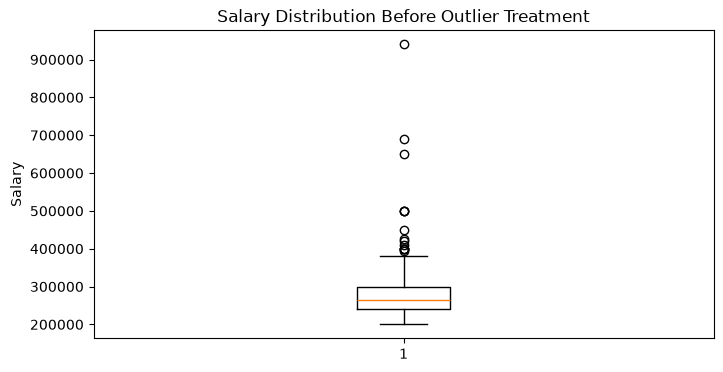

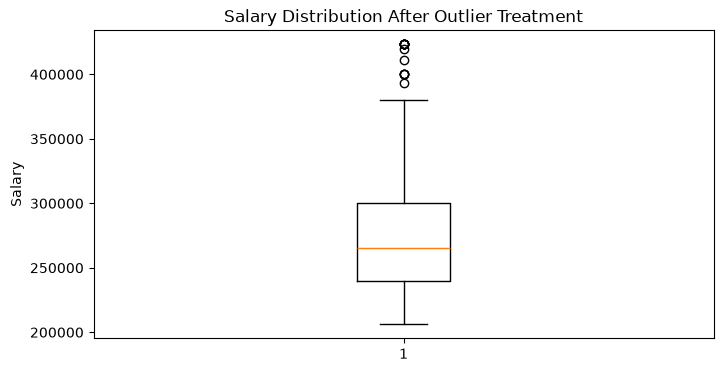

5th percentile: 206100.0
95th percentile: 423250.0

Salary after capping/flooring:
count       148.000000
mean     280356.756757
std       59315.101336
min      206100.000000
25%      240000.000000
50%      265000.000000
75%      300000.000000
max      423250.000000
Name: salary, dtype: float64


In [19]:

import matplotlib.pyplot as plt
lower_limit = DF["salary"].quantile(0.05)
upper_limit = DF["salary"].quantile(0.95)

DF["salary_before_capping"] = DF["salary"]

plt.figure(figsize=(8, 4))
plt.boxplot(DF["salary"].dropna())
plt.title("Salary Distribution Before Outlier Treatment")
plt.ylabel("Salary")
plt.show()

DF["salary"] = DF["salary"].clip(
    lower=lower_limit,
    upper=upper_limit
)

plt.figure(figsize=(8, 4))
plt.boxplot(DF["salary"].dropna())
plt.title("Salary Distribution After Outlier Treatment")
plt.ylabel("Salary")
plt.show()

print("5th percentile:", lower_limit)
print("95th percentile:", upper_limit)
print("\nSalary after capping/flooring:")
print(DF["salary"].describe())

## Step 7: Convert categorical variables into numerical format using LabelEncoder ().
[![Picture1.png](https://i.postimg.cc/yNpNvnVd/Picture1.png)](https://postimg.cc/zLW5fCHZ)




In [20]:
categorical_columns = ["gender", "hsc_s", "degree_t", "specialisation"]

label_encoders = {}

for col in categorical_columns:
    encoder = LabelEncoder()
    DF[col + "_encoded"] = encoder.fit_transform(DF[col].astype(str))
    label_encoders[col] = encoder

for col in categorical_columns:
    print("\n", col)
    print(DF[[col, col + "_encoded"]].drop_duplicates().sort_values(col).to_string(index=False))
    print("Mapping:", dict(zip(label_encoders[col].classes_,
                              label_encoders[col].transform(label_encoders[col].classes_))))


 gender
gender  gender_encoded
     F               0
     M               1
Mapping: {'F': np.int64(0), 'M': np.int64(1)}

 hsc_s
   hsc_s  hsc_s_encoded
    Arts              0
Commerce              1
 Science              2
Mapping: {'Arts': np.int64(0), 'Commerce': np.int64(1), 'Science': np.int64(2)}

 degree_t
 degree_t  degree_t_encoded
Comm&Mgmt                 0
   Others                 1
 Sci&Tech                 2
Mapping: {'Comm&Mgmt': np.int64(0), 'Others': np.int64(1), 'Sci&Tech': np.int64(2)}

 specialisation
specialisation  specialisation_encoded
       Mkt&Fin                       0
        Mkt&HR                       1
Mapping: {'Mkt&Fin': np.int64(0), 'Mkt&HR': np.int64(1)}


## Convert categorical variables into numerical format using one hot encoder

[![Picture2.png](https://i.postimg.cc/gcZ0Hv1J/Picture2.png)](https://postimg.cc/HjTHp7YD)

In [21]:

DF_onehot = pd.get_dummies(
    DF,
    columns=categorical_columns,
    dtype=int
)

DF_onehot.head()


,sl_no,hsc_p,degree_p,etest_p,mba_p,salary,salary_zscore,salary_before_capping,gender_encoded,hsc_s_encoded,...,gender_F,gender_M,hsc_s_Arts,hsc_s_Commerce,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,specialisation_Mkt&Fin,specialisation_Mkt&HR
0,1,91.00000,58.00,55.0,58.80,270000.0,-0.200292,270000.0,1,1,...,0,1,0,1,0,0,0,1,0,1
1,2,78.33000,77.48,86.5,66.28,206100.0,-0.951839,200000.0,1,2,...,0,1,0,0,1,0,0,1,1,0
2,3,70.00089,64.00,75.0,57.80,250000.0,-0.415019,250000.0,1,0,...,0,1,1,0,0,1,0,0,1,0
4,5,73.60000,73.30,96.8,55.50,423250.0,1.463849,425000.0,1,1,...,0,1,0,1,0,1,0,0,1,0
7,8,64.00000,66.00,67.0,62.14,252000.0,-0.393547,252000.0,1,2,...,0,1,0,0,1,0,0,1,1,0


In [22]:
print("Missing values:")
print(DF_onehot.isnull().sum().sum())

print("\nData types:")
print(DF_onehot.dtypes)

print("\nShape:")
print(DF_onehot.shape)

DF_onehot.head()

Missing values:
0

Data types:
sl_no                       int64
hsc_p                     float64
degree_p                  float64
etest_p                   float64
mba_p                     float64
salary                    float64
salary_zscore             float64
salary_before_capping     float64
gender_encoded              int64
hsc_s_encoded               int64
degree_t_encoded            int64
specialisation_encoded      int64
gender_F                    int64
gender_M                    int64
hsc_s_Arts                  int64
hsc_s_Commerce              int64
hsc_s_Science               int64
degree_t_Comm&Mgmt          int64
degree_t_Others             int64
degree_t_Sci&Tech           int64
specialisation_Mkt&Fin      int64
specialisation_Mkt&HR       int64
dtype: object

Shape:
(148, 22)


,sl_no,hsc_p,degree_p,etest_p,mba_p,salary,salary_zscore,salary_before_capping,gender_encoded,hsc_s_encoded,...,gender_F,gender_M,hsc_s_Arts,hsc_s_Commerce,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,specialisation_Mkt&Fin,specialisation_Mkt&HR
0,1,91.00000,58.00,55.0,58.80,270000.0,-0.200292,270000.0,1,1,...,0,1,0,1,0,0,0,1,0,1
1,2,78.33000,77.48,86.5,66.28,206100.0,-0.951839,200000.0,1,2,...,0,1,0,0,1,0,0,1,1,0
2,3,70.00089,64.00,75.0,57.80,250000.0,-0.415019,250000.0,1,0,...,0,1,1,0,0,1,0,0,1,0
4,5,73.60000,73.30,96.8,55.50,423250.0,1.463849,425000.0,1,1,...,0,1,0,1,0,1,0,0,1,0
7,8,64.00000,66.00,67.0,62.14,252000.0,-0.393547,252000.0,1,2,...,0,1,0,0,1,0,0,1,1,0


In [23]:
Final = DF_onehot.copy()

helper_columns = [
    "salary_zscore",
    "salary_before_capping"
]
Final.drop(columns=helper_columns, errors="ignore", inplace=True)

Final.to_csv("Final.csv", index=False)

print("Final.csv saved successfully.")
print("Final dataset shape:", Final.shape)
Final.head()


Final.csv saved successfully.
Final dataset shape: (148, 20)


,sl_no,hsc_p,degree_p,etest_p,mba_p,salary,gender_encoded,hsc_s_encoded,degree_t_encoded,specialisation_encoded,gender_F,gender_M,hsc_s_Arts,hsc_s_Commerce,hsc_s_Science,degree_t_Comm&Mgmt,degree_t_Others,degree_t_Sci&Tech,specialisation_Mkt&Fin,specialisation_Mkt&HR
0,1,91.00000,58.00,55.0,58.80,270000.0,1,1,2,1,0,1,0,1,0,0,0,1,0,1
1,2,78.33000,77.48,86.5,66.28,206100.0,1,2,2,0,0,1,0,0,1,0,0,1,1,0
2,3,70.00089,64.00,75.0,57.80,250000.0,1,0,0,0,0,1,1,0,0,1,0,0,1,0
4,5,73.60000,73.30,96.8,55.50,423250.0,1,1,0,0,0,1,0,1,0,1,0,0,1,0
7,8,64.00000,66.00,67.0,62.14,252000.0,1,2,2,0,0,1,0,0,1,0,0,1,1,0


# Exercise: Data Cleaning and Transformation – Automobile Dataset

## Step 1: Load and Explore the Dataset

### 1. Load the Dataset
- Import Pandas and load the Automobile dataset.
- Display the first 10 rows.
- Display the shape of the dataset.

### 2. Explore the Dataset
- Display the column names.
- Display the data types.
- Generate descriptive statistics.
- Identify numerical and categorical columns.
- Display unique values in categorical columns.

## Step 2: Data Cleaning

### 3. Check Missing Values
- Check for missing values in each column.
- Display the number and percentage of missing values.

### 4. Handle Missing Values
- Replace missing numerical values using mean or median.
- Replace missing categorical values using mode.
- Verify that no missing values remain.

### 5. Remove Duplicate Records
- Check for duplicate rows.
- Display the number of duplicate records.
- Remove duplicate records.
- Verify the result.

### 6. Clean the `horsepower` Column
- Identify non-numeric values such as `?`.
- Replace `?` with `NaN`.
- Convert `horsepower` to numeric.
- Handle the resulting missing values.

## Step 3: Data Transformation

### 7. Transform the `origin` Column
- Display the unique values in `origin`.
- Convert the values into meaningful labels:
  - `1` → `usa`
  - `2` → `europe`
  - `3` → `japan`

### 8. Create `weight_kg`
- Create a new column `weight_kg`.
- Convert weight from pounds to kilograms.

  `weight_kg = weight × 0.453592`

### 9. Create `mpg_category`
Create a new column based on `mpg`:
- `< 20` → `Low`
- `20–29` → `Medium`
- `≥ 30` → `High`

### 10. Create `vehicle_age`
- Create a new column `vehicle_age`.
- Assume the current year is 2026.

  `vehicle_age = 2026 - model_year`

### 11. Rename Columns
Rename:
- `mpg` → `miles_per_gallon`
- `horsepower` → `hp`
- `weight` → `weight_lbs`
- `model_year` → `year`

### 12. Filter the Data
Display vehicles:
- With `mpg > 30`
- With `horsepower > 150`
- With `cylinders >= 6`
- Manufactured after 1980
- Originating from `usa`

## Step 4: Encoding Categorical Data

### 13. Label Encoding
- Apply `LabelEncoder` to the `origin` column.
- Create a new column `origin_encoded`.
- Display the original and encoded values.
- Display the category-to-label mapping.

### 14. One-Hot Encoding
- Apply One-Hot Encoding to the `origin` column.
- Compare Label Encoding and One-Hot Encoding.
- Which encoding method is more appropriate for `origin`? Explain why.

## Step 5: Outlier Detection

### 15. Identify Outliers Using Z-Scores
- Calculate the Z-score for the numerical features.
- Identify observations with `|Z-score| > 3` as outliers.
- Count the outliers in each numerical column.
- Display the rows containing outliers.
- Decide whether the outliers should be removed or retained.

## Step 6: Feature Scaling

### 16. Standardization Using StandardScaler
- Select the numerical features.
- Apply `StandardScaler`.
- Display the standardized values.
- Verify that the features have approximately mean `0` and standard deviation `1`.

## Step 7: Normalization

### 17. Normalization Using MinMaxScaler
- Apply `MinMaxScaler` to the numerical features.
- Transform the features to the range `[0, 1]`.
- Display the normalized values.
- Compare **Standardization** and **Normalization**.
- Explain when each scaling method is appropriate.

## Step 8: Create Features and Target

### 18. Create X and Y Variables
- Select the appropriate input features as **X (independent variables)**.
- Select `mpg` as **Y (target variable)**.
- Display the shape of `X` and `Y`.
- Save `X` and `Y` into `automobile_X_Y.csv`.
- Load the CSV file again and display the first 5 rows.

## Step 9: Save the Final Dataset

### 19. Save the Preprocessed Dataset
- Combine the processed features and target variable.
- Display the final dataset.
- Check for missing values.
- Save the final dataset as `automobile_preprocessed.csv`.

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from scipy.stats import zscore

auto = pd.read_csv("Automobile.csv")

print("First 10 rows:")
display(auto.head(10))

print("Shape:", auto.shape)

print("\nColumn names:")
print(auto.columns.tolist())

print("\nData types:")
print(auto.dtypes)

print("\nDescriptive statistics:")
display(auto.describe(include="all"))

numerical_cols = auto.select_dtypes(include=np.number).columns.tolist()
categorical_cols = auto.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(auto[col].unique())

missing_count = auto.isnull().sum()
missing_percentage = (missing_count / len(auto)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print("\nMissing-value summary:")
display(missing_summary)

for col in auto.select_dtypes(include=np.number).columns:
    auto[col] = auto[col].fillna(auto[col].median())

for col in auto.select_dtypes(exclude=np.number).columns:
    if auto[col].isnull().any():
        auto[col] = auto[col].fillna(auto[col].mode()[0])

print("\nMissing values after imputation:")
print(auto.isnull().sum())

duplicate_count = auto.duplicated().sum()
print("\nNumber of duplicate records:", duplicate_count)

auto.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", auto.shape)
print("Remaining duplicate records:", auto.duplicated().sum())

if "horsepower" in auto.columns:
    auto["horsepower"] = auto["horsepower"].replace("?", np.nan)
    auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")
    auto["horsepower"] = auto["horsepower"].fillna(auto["horsepower"].median())

print("\nHorsepower dtype:", auto["horsepower"].dtype)
print("Missing horsepower:", auto["horsepower"].isnull().sum())

print("\nOriginal origin values:")
print(auto["origin"].unique())

origin_map = {
    1: "usa",
    2: "europe",
    3: "japan"
}

auto["origin"] = auto["origin"].map(origin_map).fillna(auto["origin"])

print("\nTransformed origin values:")
print(auto["origin"].unique())

auto["weight_kg"] = auto["weight"] * 0.453592

auto["mpg_category"] = pd.cut(
    auto["mpg"],
    bins=[-np.inf, 20, 30, np.inf],
    labels=["Low", "Medium", "High"],
    right=False
)

auto["vehicle_age"] = 2026 - auto["model_year"]

auto.rename(columns={
    "mpg": "miles_per_gallon",
    "horsepower": "hp",
    "weight": "weight_lbs",
    "model_year": "year"
}, inplace=True)

print("\nColumns after transformation:")
print(auto.columns.tolist())
print("\nVehicles with mpg > 30:")
display(auto[auto["miles_per_gallon"] > 30].head())

print("\nVehicles with horsepower > 150:")
display(auto[auto["hp"] > 150].head())

print("\nVehicles with cylinders >= 6:")
display(auto[auto["cylinders"] >= 6].head())

print("\nVehicles manufactured after 1980:")
display(auto[auto["year"] > 1980].head())

print("\nVehicles originating from USA:")
display(auto[auto["origin"] == "usa"].head())

origin_encoder = LabelEncoder()
auto["origin_encoded"] = origin_encoder.fit_transform(auto["origin"])

print("\nOrigin encoding:")
display(auto[["origin", "origin_encoded"]].drop_duplicates())

origin_mapping = dict(zip(
    origin_encoder.classes_,
    origin_encoder.transform(origin_encoder.classes_)
))
print("Category-to-label mapping:", origin_mapping)

auto_onehot = pd.get_dummies(
    auto,
    columns=["origin"],
    prefix="origin",
    dtype=int
)

print("\nOne-Hot encoded dataset:")
display(auto_onehot.head())

print("\nLabel Encoding vs One-Hot Encoding:")
print("Label encoding uses one integer per category.")
print("One-Hot Encoding creates separate binary columns.")
print("For origin, One-Hot Encoding is generally more appropriate because")
print("USA, Europe and Japan are nominal categories with no natural order.")

outlier_numeric = auto.select_dtypes(include=np.number).columns.tolist()

z_scores = auto[outlier_numeric].apply(zscore)

outlier_counts = (z_scores.abs() > 3).sum()

print("\nOutlier count in each numerical column:")
print(outlier_counts)

outlier_rows = auto[(z_scores.abs() > 3).any(axis=1)]

print("\nRows containing at least one |Z-score| > 3 outlier:")
display(outlier_rows)

print("\nDecision:")
print("Potential outliers should be investigated before removal.")
print("They can be retained when they represent genuine vehicles or")
print("removed/treated when they are data-entry errors or extreme noise.")
scale_cols = [
    col for col in [
        "cylinders", "displacement", "hp", "weight_lbs",
        "acceleration", "year", "origin_encoded",
        "weight_kg", "vehicle_age"
    ]
    if col in auto.columns
]

standard_scaler = StandardScaler()
auto_standardized = auto.copy()

auto_standardized[scale_cols] = standard_scaler.fit_transform(
    auto_standardized[scale_cols]
)

print("\nStandardized values:")
display(auto_standardized[scale_cols].head())

print("\nApproximate means after standardization:")
print(auto_standardized[scale_cols].mean().round(6))

print("\nApproximate standard deviations:")
print(auto_standardized[scale_cols].std().round(6))

minmax_scaler = MinMaxScaler()
auto_normalized = auto.copy()

auto_normalized[scale_cols] = minmax_scaler.fit_transform(
    auto_normalized[scale_cols]
)

print("\nNormalized values:")
display(auto_normalized[scale_cols].head())

print("\nMinimum values after normalization:")
print(auto_normalized[scale_cols].min().round(6))

print("\nMaximum values after normalization:")
print(auto_normalized[scale_cols].max().round(6))

print("\nComparison:")
print("Standardization transforms features to mean 0 and standard deviation 1.")
print("Normalization transforms features to the range 0 to 1.")
print("Standardization is useful when features have different distributions")
print("and when algorithms work better with centered data.")
print("Normalization is useful when a fixed bounded range is desired.")

Y = auto["miles_per_gallon"].copy()

X = auto_onehot.drop(columns=["miles_per_gallon"], errors="ignore").copy()

bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

X = pd.get_dummies(X, drop_first=False, dtype=int)

XY = X.copy()
XY["mpg"] = Y.values

print("\nX shape:", X.shape)
print("Y shape:", Y.shape)

XY.to_csv("automobile_X_Y.csv", index=False)

print("\nautomobile_X_Y.csv saved successfully.")

loaded_XY = pd.read_csv("automobile_X_Y.csv")
print("\nFirst 5 rows after loading the saved CSV:")
display(loaded_XY.head())

automobile_preprocessed = XY.copy()

print("\nFinal preprocessed dataset:")
display(automobile_preprocessed.head())

print("\nMissing values in final dataset:")
print(automobile_preprocessed.isnull().sum().sum())

print("\nFinal data types:")
print(automobile_preprocessed.dtypes)

print("\nFinal shape:", automobile_preprocessed.shape)

automobile_preprocessed.to_csv(
    "automobile_preprocessed.csv",
    index=False
)

print("\nautomobile_preprocessed.csv saved successfully.")


First 10 rows:


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,70,usa
1,buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,70,usa
2,plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,70,usa
3,amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,70,usa
4,ford torino,17.0,NaN,302.0,140.0,3449.0,10.5,70,usa
5,ford galaxie 500,15.0,8.0,429.0,198.0,4341.0,10.0,70,usa
6,chevrolet impala,14.0,8.0,454.0,220.0,NaN,9.0,70,usa
7,plymouth fury iii,14.0,8.0,440.0,215.0,4312.0,8.5,70,usa
8,pontiac catalina,14.0,8.0,455.0,NaN,4425.0,10.0,70,usa
9,amc ambassador dpl,15.0,8.0,390.0,190.0,3850.0,8.5,70,usa


Shape: (398, 9)

Column names:
['name', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

Data types:
name                str
mpg             float64
cylinders       float64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin              str
dtype: object

Descriptive statistics:


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398,398.000000,395.000000,395.000000,386.000000,396.000000,395.000000,398.000000,398
unique,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,ford pinto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,usa
freq,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,249
mean,NaN,23.514573,5.445570,193.340506,104.316062,2965.025253,15.562278,76.010050,NaN
std,NaN,7.815984,1.696203,104.425993,38.086281,845.254458,2.750260,3.697627,NaN
min,NaN,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,NaN
25%,NaN,17.500000,4.000000,102.500000,75.250000,2222.250000,13.850000,73.000000,NaN
50%,NaN,23.000000,4.000000,146.000000,92.500000,2797.500000,15.500000,76.000000,NaN
75%,NaN,29.000000,8.000000,262.000000,125.000000,3581.750000,17.150000,79.000000,NaN



Numerical columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Categorical columns: ['name', 'origin']

Unique values in categorical columns:

name:
<StringArray>
[ 'chevrolet chevelle malibu',          'buick skylark 320',
         'plymouth satellite',              'amc rebel sst',
                'ford torino',           'ford galaxie 500',
           'chevrolet impala',          'plymouth fury iii',
           'pontiac catalina',         'amc ambassador dpl',
 ...
 'chrysler lebaron medallion',             'ford granada l',
           'toyota celica gt',          'dodge charger 2.2',
           'chevrolet camaro',            'ford mustang gl',
                  'vw pickup',              'dodge rampage',
                'ford ranger',                 'chevy s-10']
Length: 305, dtype: str

origin:
<StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str

Missing-value summary:


...


Minimum values after normalization:
cylinders         0.0
displacement      0.0
hp                0.0
weight_lbs        0.0
acceleration      0.0
year              0.0
origin_encoded    0.0
weight_kg         0.0
vehicle_age       0.0
dtype: float64

Maximum values after normalization:
cylinders         1.0
displacement      1.0
hp                1.0
weight_lbs        1.0
acceleration      1.0
year              1.0
origin_encoded    1.0
weight_kg         1.0
vehicle_age       1.0
dtype: float64

Comparison:
Standardization transforms features to mean 0 and standard deviation 1.
Normalization transforms features to the range 0 to 1.
Standardization is useful when features have different distributions
and when algorithms work better with centered data.
Normalization is useful when a fixed bounded range is desired.

X shape: (398, 320)
Y shape: (398,)

automobile_X_Y.csv saved successfully.

First 5 rows after loading the saved CSV:


,cylinders,displacement,hp,weight_lbs,acceleration,year,weight_kg,vehicle_age,origin_encoded,origin_europe,...,name_volvo diesel,name_vw dasher (diesel),name_vw pickup,name_vw rabbit,name_vw rabbit c (diesel),name_vw rabbit custom,mpg_category_Low,mpg_category_Medium,mpg_category_High,mpg
0,8.0,307.0,130.0,3504.0,12.0,70,1589.386368,1956,2,0,...,0,0,0,0,0,0,1,0,0,18.0
1,8.0,350.0,165.0,3693.0,11.5,70,1675.115256,1956,2,0,...,0,0,0,0,0,0,1,0,0,15.0
2,8.0,318.0,150.0,3436.0,11.0,70,1558.542112,1956,2,0,...,0,0,0,0,0,0,1,0,0,18.0
3,8.0,304.0,150.0,3433.0,12.0,70,1557.181336,1956,2,0,...,0,0,0,0,0,0,1,0,0,16.0
4,4.0,302.0,140.0,3449.0,10.5,70,1564.438808,1956,2,0,...,0,0,0,0,0,0,1,0,0,17.0



Final preprocessed dataset:


,cylinders,displacement,hp,weight_lbs,acceleration,year,weight_kg,vehicle_age,origin_encoded,origin_europe,...,name_volvo diesel,name_vw dasher (diesel),name_vw pickup,name_vw rabbit,name_vw rabbit c (diesel),name_vw rabbit custom,mpg_category_Low,mpg_category_Medium,mpg_category_High,mpg
0,8.0,307.0,130.0,3504.0,12.0,70,1589.386368,1956,2,0,...,0,0,0,0,0,0,1,0,0,18.0
1,8.0,350.0,165.0,3693.0,11.5,70,1675.115256,1956,2,0,...,0,0,0,0,0,0,1,0,0,15.0
2,8.0,318.0,150.0,3436.0,11.0,70,1558.542112,1956,2,0,...,0,0,0,0,0,0,1,0,0,18.0
3,8.0,304.0,150.0,3433.0,12.0,70,1557.181336,1956,2,0,...,0,0,0,0,0,0,1,0,0,16.0
4,4.0,302.0,140.0,3449.0,10.5,70,1564.438808,1956,2,0,...,0,0,0,0,0,0,1,0,0,17.0



Missing values in final dataset:
0

Final data types:
cylinders                float64
displacement             float64
hp                       float64
weight_lbs               float64
acceleration             float64
                          ...   
name_vw rabbit custom      int64
mpg_category_Low           int64
mpg_category_Medium        int64
mpg_category_High          int64
mpg                      float64
Length: 321, dtype: object

Final shape: (398, 321)

automobile_preprocessed.csv saved successfully.
